In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import ndx_fiber_photometry  # noqa: F401 — registers extension
import ndx_ophys_devices  # noqa: F401 — registers extension
import numpy as np
from pynwb import read_nwb

warnings.filterwarnings("ignore", category=UserWarning)

## 1. Open the NWB file and list processed series

In [2]:
# ── Point this at an NWB file produced by convert_session.py ─────────────────
NWB_PATH = Path("../../../nwb_output/sub-400_ses-119247.nwb")

nwb = read_nwb(NWB_PATH)

print("Session ID     :", nwb.session_id)
print("Session start  :", nwb.session_start_time)
print("Subject        :", nwb.subject.subject_id)
print()

Session ID     : 119247
Session start  : 2025-10-02 11:48:47-07:00
Subject        : 400



In [3]:
from ndx_fiber_photometry import FiberPhotometryResponseSeries

ophys = nwb.processing["ophys"]
proc_series = {
    name: obj
    for name, obj in ophys.data_interfaces.items()
    if isinstance(obj, FiberPhotometryResponseSeries)
}

print(f"{len(proc_series)} FiberPhotometryResponseSeries in processing['ophys']:\n")
for name, s in proc_series.items():
    n, ncols = s.data.shape
    if s.rate is not None:
        timing = f"rate={s.rate:.2f} Hz, t0={s.starting_time:.4f} s"
    else:
        ts = s.timestamps
        rate_est = (len(ts) - 1) / (float(ts[-1]) - float(ts[0]))
        timing = f"~{rate_est:.2f} Hz (from timestamps), t0={float(ts[0]):.4f} s"
    print(f"  {name}")
    print(f"    shape=({n:,}, {ncols}), {timing}, unit={s.unit}")

12 FiberPhotometryResponseSeries in processing['ophys']:

  FiberPhotometryResponseSeriesBaselineCorrectedIsosbestic
    shape=(888,457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesBaselineCorrectedSignal
    shape=(888,457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesBaselineIsosbestic
    shape=(888,457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesBaselineSignal
    shape=(888,457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesDFF
    shape=(888,457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesDFFFreqBandCorrected
    shape=(888,457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesDecimatedIsosbestic
    shape=(888,457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesDecimatedSignal
    shape=(888,457, 4), rate=200.80 Hz, t0=0.0855 s, unit=a.u.
  FiberPhotometryResponseSeriesFilteredIsos

## 2. Decode column → brain region mapping

Each series stores one column per AIN channel. The brain region for each column is
looked up from the `FiberPhotometryTable` rows referenced by
`fiber_photometry_table_region`.

In [4]:
fp_table = nwb.lab_meta_data["fiber_photometry"].fiber_photometry_table
fp_df = fp_table.to_dataframe()

# Use the DFF series to decode column order (all processed series share the same layout).
dff_series = proc_series["FiberPhotometryResponseSeriesDFF"]
col_row_idx = list(dff_series.fiber_photometry_table_region.data[:])
col_regions = [fp_df.iloc[i]["location"] for i in col_row_idx]

print("Column → brain region mapping (from FiberPhotometryTable):")
for col, (row_i, region) in enumerate(zip(col_row_idx, col_regions)):
    print(f"  col {col}  (table row {row_i})  →  {region}")

Column → brain region mapping (from FiberPhotometryTable):
  col 0  (table row 4)  →  Dorsolateral striatum
  col 1  (table row 5)  →  Prelimbic area
  col 2  (table row 6)  →  Dorsomedial striatum
  col 3  (table row 7)  →  Nucleus accumbens


In [5]:
SIGNAL_COLOR = {
    "Nucleus accumbens":     "#9C27B0",
    "Dorsolateral striatum": "#2196F3",
    "Dorsomedial striatum":  "#4CAF50",
    "Prelimbic area":        "#FF5722",
    "Tail of striatum":      "#FF9800",
}

## 3. Full-session overview — decimated raw signals

The decimated raw signals (30× downsampled from the 6024 Hz Doric clock) are the
starting point for the processing pipeline. Grey = isosbestic, colored = ligand.

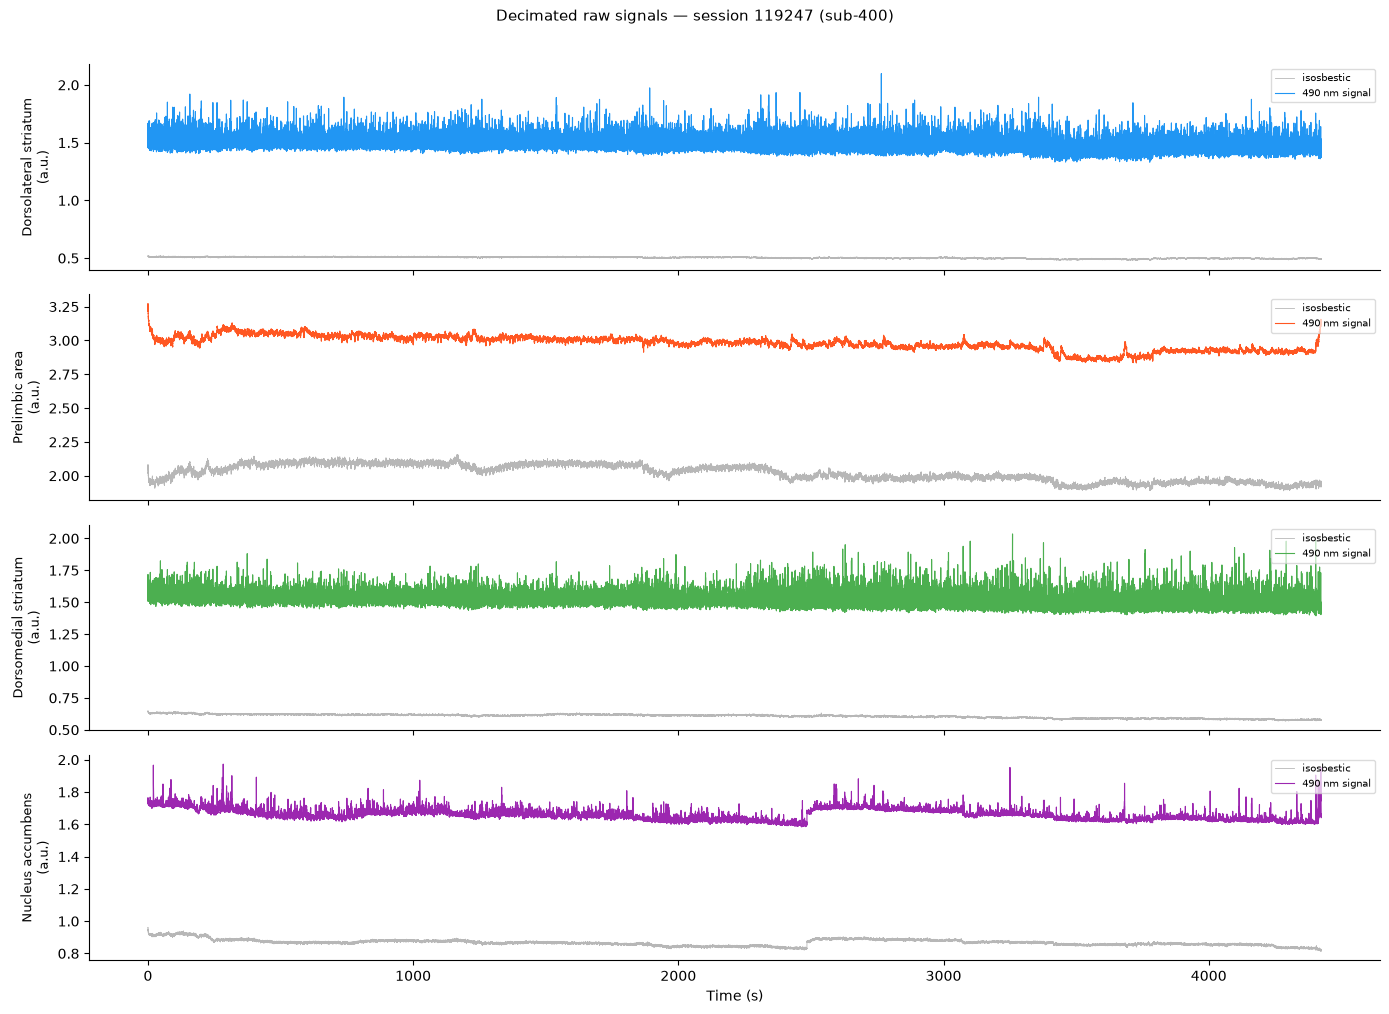

In [6]:
iso_dec = proc_series["FiberPhotometryResponseSeriesDecimatedIsosbestic"]
lig_dec = proc_series["FiberPhotometryResponseSeriesDecimatedSignal"]

# Decode iso column order (linked to iso table rows, not sig rows)
iso_row_idx = list(iso_dec.fiber_photometry_table_region.data[:])
iso_col_regions = [fp_df.iloc[i]["location"] for i in iso_row_idx]

ts = lig_dec.get_timestamps()

fig, axes = plt.subplots(len(col_regions), 1, figsize=(14, 2.5 * len(col_regions)), sharex=True)
if len(col_regions) == 1:
    axes = [axes]

for col_idx, (ax, region) in enumerate(zip(axes, col_regions)):
    iso_col = iso_col_regions.index(region)  # iso series may have different column order
    color = SIGNAL_COLOR.get(region, "steelblue")
    ax.plot(ts, iso_dec.data[:, iso_col], color="#999", lw=0.6,
            alpha=0.7, label="isosbestic", rasterized=True)
    ax.plot(ts, lig_dec.data[:, col_idx], color=color, lw=0.8,
            alpha=1.0, label="490 nm signal", rasterized=True)
    ax.set_ylabel(f"{region}\n(a.u.)", fontsize=9)
    ax.legend(loc="upper right", fontsize=7, framealpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Decimated raw signals — session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 4. Processing pipeline walkthrough — one region

The cell below shows all intermediate processing stages for a single region.
Change `REGION` to any of the available regions.

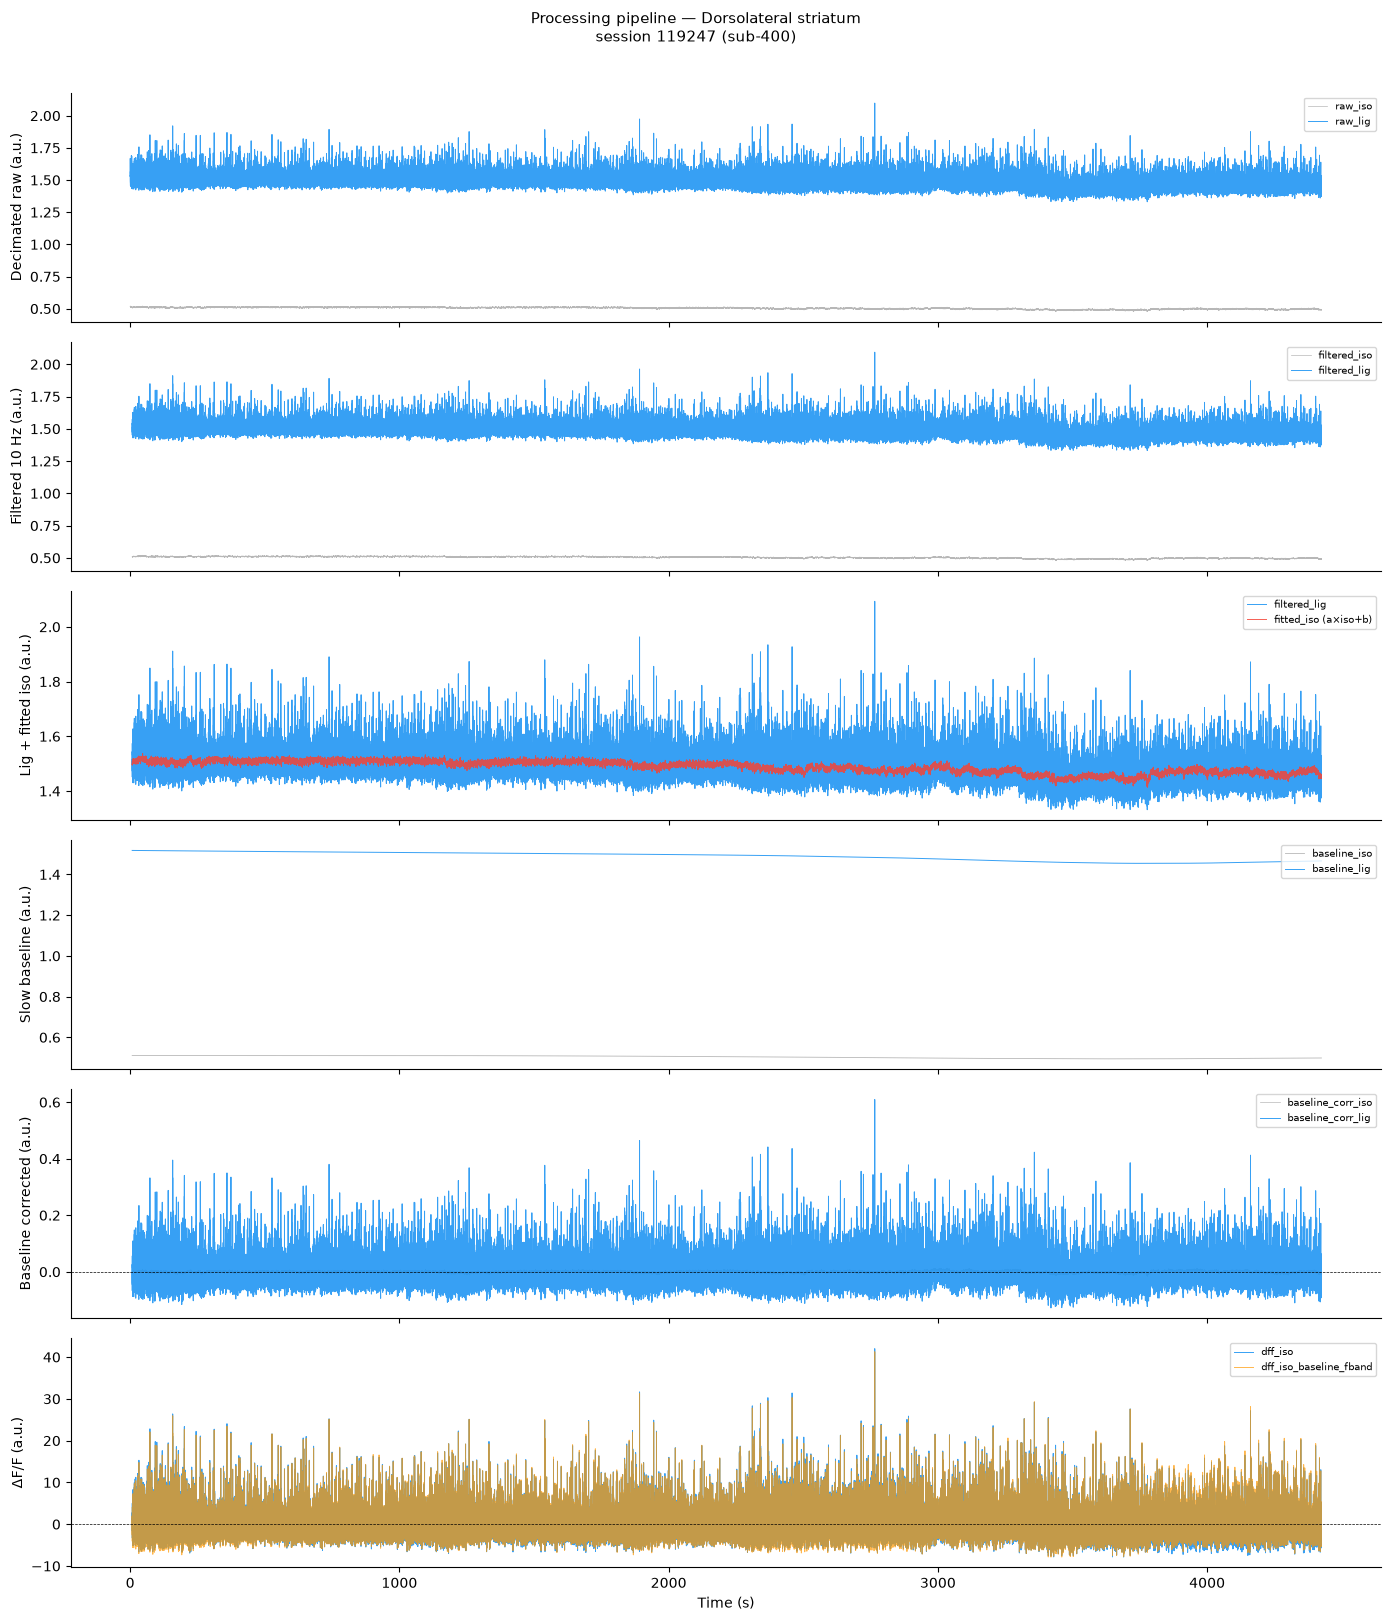

In [7]:
REGION = col_regions[0]  # change to any available region

# Column index in the signal-wavelength series (col_regions order)
sig_col = col_regions.index(REGION)
# Column index in the iso-wavelength series
iso_col = iso_col_regions.index(REGION)

def get_col(series_name, col):
    return np.asarray(proc_series[series_name].data[:, col])

raw_iso   = get_col("FiberPhotometryResponseSeriesDecimatedIsosbestic",         iso_col)
raw_lig   = get_col("FiberPhotometryResponseSeriesDecimatedSignal",             sig_col)
filt_iso  = get_col("FiberPhotometryResponseSeriesFilteredIsosbestic",          iso_col)
filt_lig  = get_col("FiberPhotometryResponseSeriesFilteredSignal",              sig_col)
fit_iso   = get_col("FiberPhotometryResponseSeriesFittedIsosbestic",            iso_col)
base_iso  = get_col("FiberPhotometryResponseSeriesBaselineIsosbestic",          iso_col)
base_lig  = get_col("FiberPhotometryResponseSeriesBaselineSignal",              sig_col)
bc_iso    = get_col("FiberPhotometryResponseSeriesBaselineCorrectedIsosbestic", iso_col)
bc_lig    = get_col("FiberPhotometryResponseSeriesBaselineCorrectedSignal",     sig_col)
fb_fit    = get_col("FiberPhotometryResponseSeriesFittedFreqBandBaselineIsosbestic", iso_col)
dff       = get_col("FiberPhotometryResponseSeriesDFF",                         sig_col)
dff_fb    = get_col("FiberPhotometryResponseSeriesDFFFreqBandCorrected",        sig_col)

color = SIGNAL_COLOR.get(REGION, "steelblue")
fig, axes = plt.subplots(6, 1, figsize=(14, 16), sharex=True)

# Row 1: decimated raw
axes[0].plot(ts, raw_iso,  color="#999",  lw=0.5, alpha=0.7, label="raw_iso",  rasterized=True)
axes[0].plot(ts, raw_lig,  color=color,   lw=0.7, alpha=0.9, label="raw_lig",  rasterized=True)
axes[0].set_ylabel("Decimated raw (a.u.)")
axes[0].legend(loc="upper right", fontsize=7)

# Row 2: filtered
axes[1].plot(ts, filt_iso, color="#999",  lw=0.5, alpha=0.7, label="filtered_iso", rasterized=True)
axes[1].plot(ts, filt_lig, color=color,   lw=0.7, alpha=0.9, label="filtered_lig", rasterized=True)
axes[1].set_ylabel("Filtered 10 Hz (a.u.)")
axes[1].legend(loc="upper right", fontsize=7)

# Row 3: filtered_lig with fitted_iso overlay
axes[2].plot(ts, filt_lig, color=color,   lw=0.7, alpha=0.9, label="filtered_lig", rasterized=True)
axes[2].plot(ts, fit_iso,  color="#F44336", lw=0.7, alpha=0.85, label="fitted_iso (a×iso+b)", rasterized=True)
axes[2].set_ylabel("Lig + fitted iso (a.u.)")
axes[2].legend(loc="upper right", fontsize=7)

# Row 4: slow baseline
axes[3].plot(ts, base_iso, color="#999",  lw=0.6, alpha=0.7, label="baseline_iso", rasterized=True)
axes[3].plot(ts, base_lig, color=color,   lw=0.7, alpha=0.9, label="baseline_lig", rasterized=True)
axes[3].set_ylabel("Slow baseline (a.u.)")
axes[3].legend(loc="upper right", fontsize=7)

# Row 5: baseline-corrected
axes[4].plot(ts, bc_iso, color="#999",  lw=0.5, alpha=0.7, label="baseline_corr_iso", rasterized=True)
axes[4].plot(ts, bc_lig, color=color,   lw=0.7, alpha=0.9, label="baseline_corr_lig", rasterized=True)
axes[4].axhline(0, color="k", lw=0.5, ls="--")
axes[4].set_ylabel("Baseline corrected (a.u.)")
axes[4].legend(loc="upper right", fontsize=7)

# Row 6: both ΔF/F
axes[5].plot(ts, dff,    color=color,     lw=0.7, alpha=0.9, label="dff_iso",                 rasterized=True)
axes[5].plot(ts, dff_fb, color="#FF9800", lw=0.7, alpha=0.7, label="dff_iso_baseline_fband", rasterized=True)
axes[5].axhline(0, color="k", lw=0.5, ls="--")
axes[5].set_ylabel("ΔF/F (a.u.)")
axes[5].legend(loc="upper right", fontsize=7)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Processing pipeline — {REGION}\n"
    f"session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 5. ΔF/F across all regions

The primary output: isosbestic-corrected ΔF/F (`dff_iso`) from all four regions.

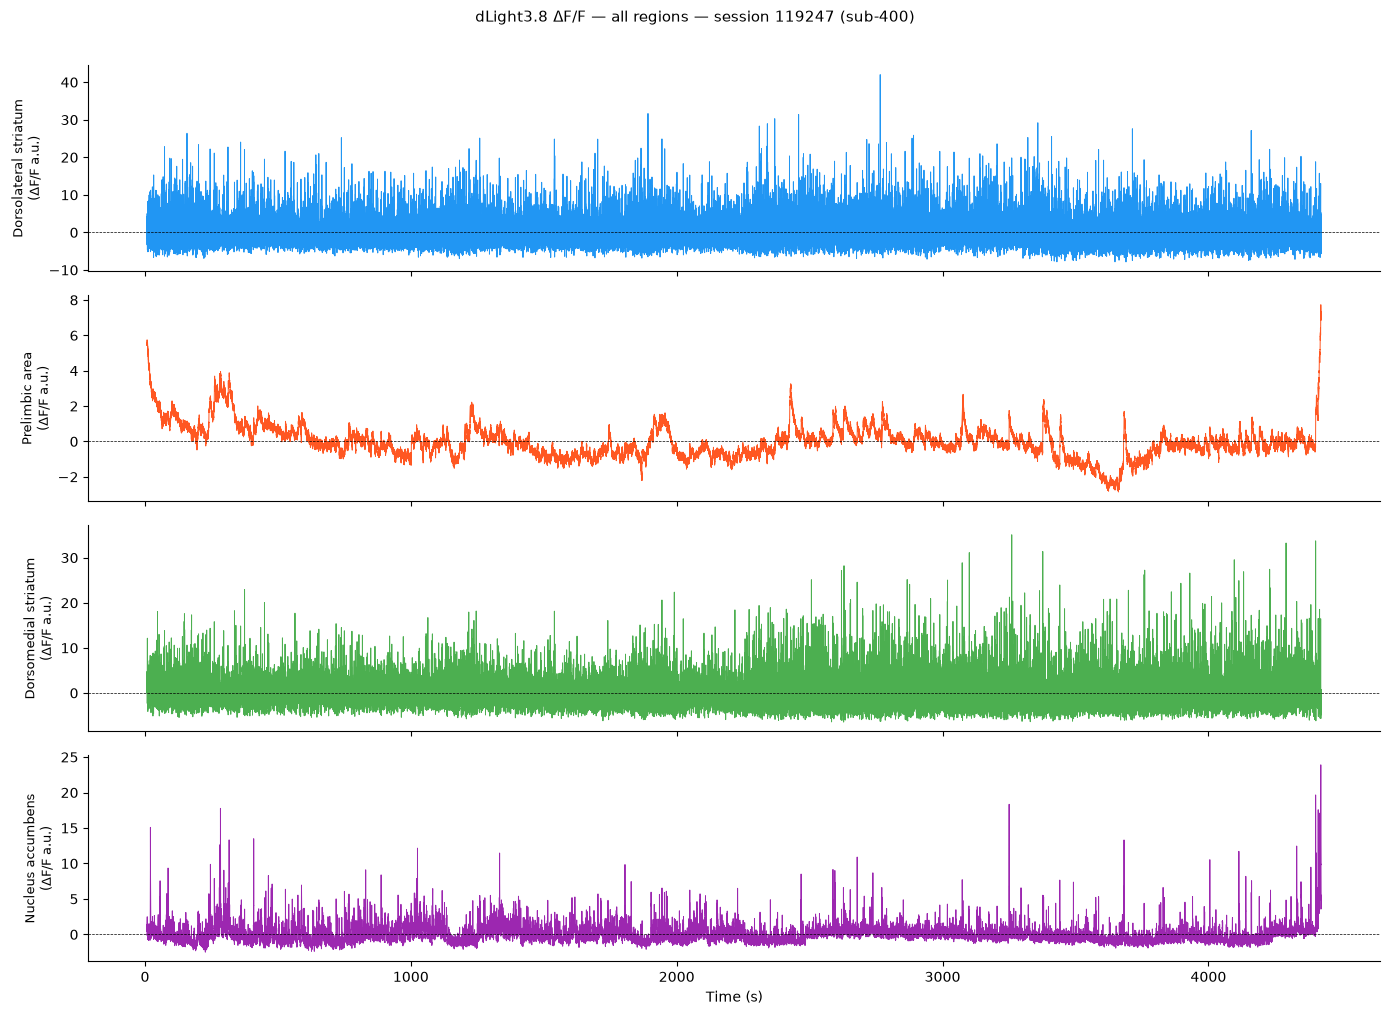

In [8]:
fig, axes = plt.subplots(len(col_regions), 1, figsize=(14, 2.5 * len(col_regions)), sharex=True)
if len(col_regions) == 1:
    axes = [axes]

for col_idx, (ax, region) in enumerate(zip(axes, col_regions)):
    color = SIGNAL_COLOR.get(region, "steelblue")
    ax.plot(ts, proc_series["FiberPhotometryResponseSeriesDFF"].data[:, col_idx],
            color=color, lw=0.7, rasterized=True)
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_ylabel(f"{region}\n(ΔF/F a.u.)", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"dLight3.8 ΔF/F — all regions — session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 6. dff_iso vs dff_iso_baseline_fband

Comparison between the two ΔF/F variants: standard linear isosbestic correction
(`dff_iso`) and the frequency-band decomposition variant (`dff_iso_baseline_fband`).
The difference is typically small (< 2 %) and most visible during slow drift periods.

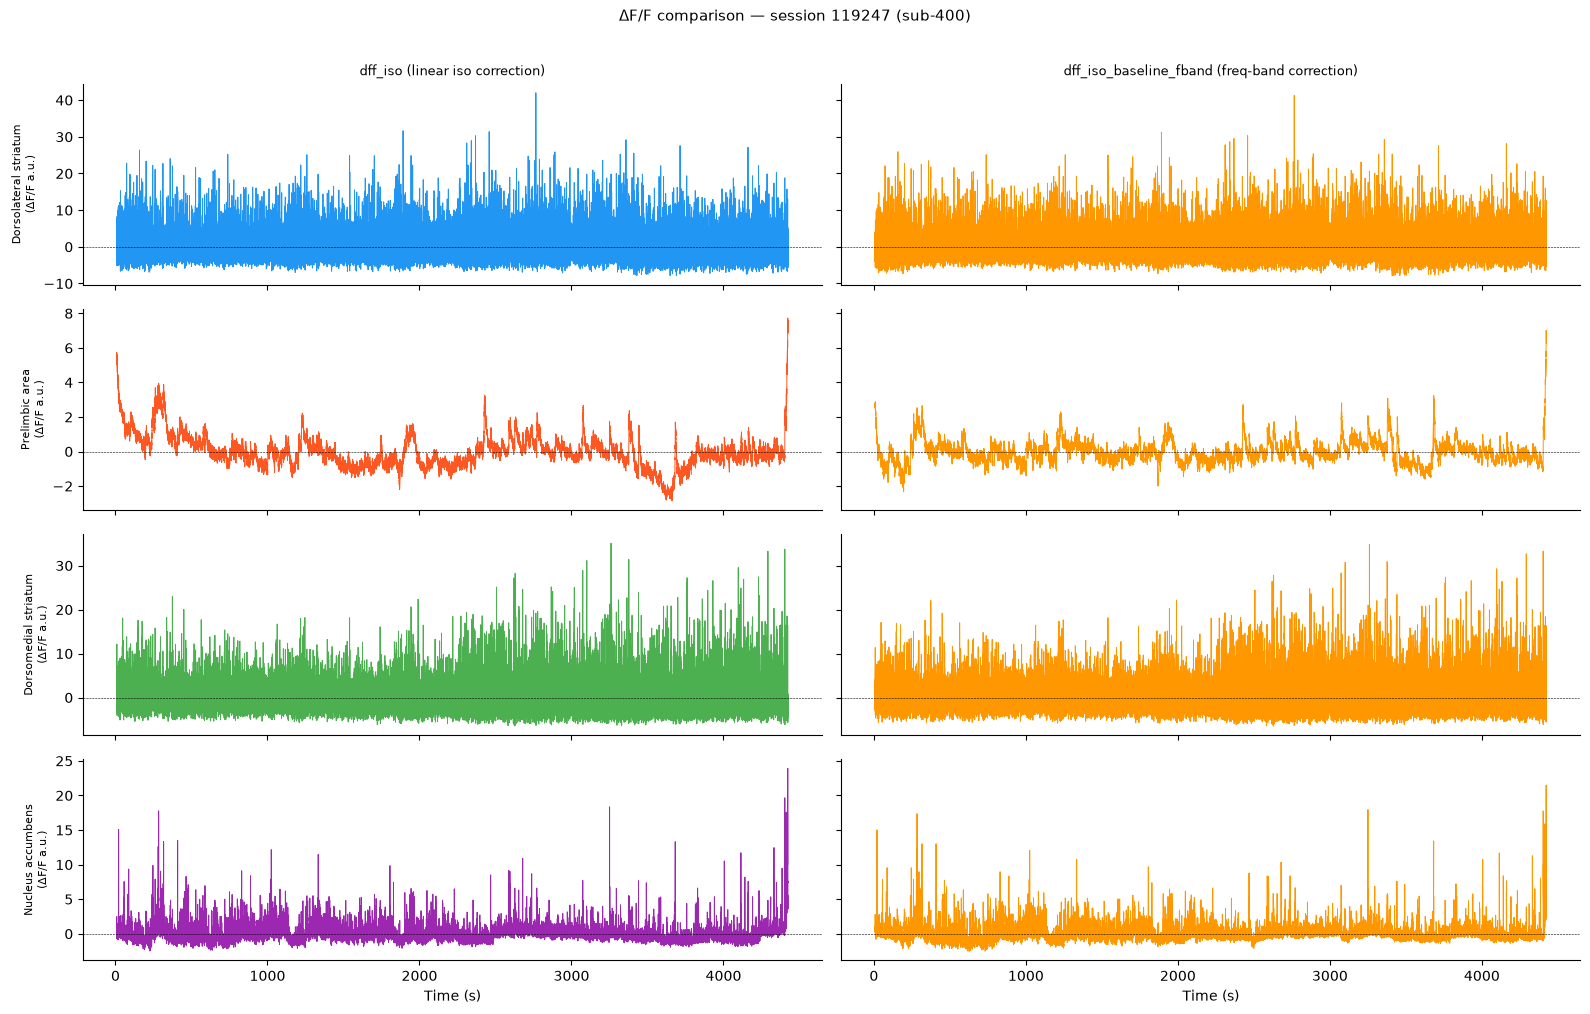

In [9]:
fig, axes = plt.subplots(len(col_regions), 2, figsize=(16, 2.5 * len(col_regions)),
                         sharex=True, sharey="row")
if len(col_regions) == 1:
    axes = axes[np.newaxis, :]

dff_s    = proc_series["FiberPhotometryResponseSeriesDFF"]
dff_fb_s = proc_series["FiberPhotometryResponseSeriesDFFFreqBandCorrected"]

for col_idx, (region, ax_row) in enumerate(zip(col_regions, axes)):
    color = SIGNAL_COLOR.get(region, "steelblue")
    d1 = np.asarray(dff_s.data[:, col_idx])
    d2 = np.asarray(dff_fb_s.data[:, col_idx])

    ax_row[0].plot(ts, d1, color=color, lw=0.7, rasterized=True)
    ax_row[0].axhline(0, color="k", lw=0.4, ls="--")
    ax_row[0].set_ylabel(f"{region}\n(ΔF/F a.u.)", fontsize=8)
    ax_row[0].spines[["top", "right"]].set_visible(False)

    ax_row[1].plot(ts, d2, color="#FF9800", lw=0.7, rasterized=True)
    ax_row[1].axhline(0, color="k", lw=0.4, ls="--")
    ax_row[1].spines[["top", "right"]].set_visible(False)

axes[0][0].set_title("dff_iso (linear iso correction)", fontsize=9)
axes[0][1].set_title("dff_iso_baseline_fband (freq-band correction)", fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel("Time (s)")

fig.suptitle(
    f"ΔF/F comparison — session {nwb.session_id} (sub-{nwb.subject.subject_id})",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

In [10]:
nwb.read_io.close()